In [30]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy.table
import astropy.units as u
from astropy.table import Table
from astropy.coordinates import SkyCoord
from crossmatching_3d import Crossmatcher3D
from crossmatching import allowed_angular_seperation


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
cm = Crossmatcher3D()
cm.search_radius_arcsec = 25 * u.arcsec
input_table = Table.read("input/HPIC_LC4_combined_d50.txt", format="ascii")
cm.load_catalog(from_file="pscomppars.txt")
cm.load_alternate_ids(input_table[cm.input_starname_key].tolist(), from_file="alternate_ids.txt")
input_table = cm.remove_duplicates(input_table)
print(f"Input: {len(input_table):,} stars | Catalog: {len(cm.catalogue):,} | IDs: {len(cm.alternate_ids):,} pairs")


Removed Rows with indecies and names: 14453, 7161, 99, 68, 2636, 235, 441
Input: 14,564 stars | Catalog: 6,291 | IDs: 285,054 pairs


3D adds 2 planet(s) (+0.2%)


,ID+3D+2D,ID+2D,Δ
,,,
matched rows,914,912,2
unique planets,853,851,2
id,861,861,0
3d,27,0,27
2d,26,51,-25


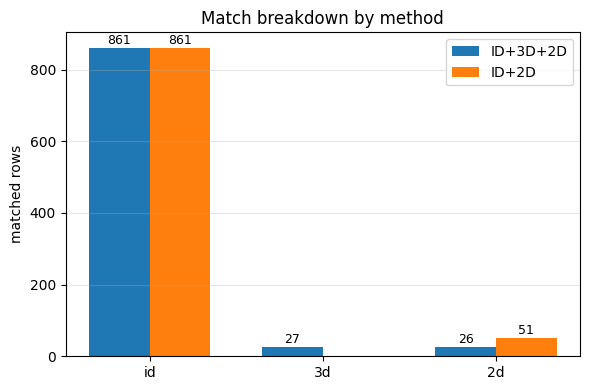

In [32]:
uuid = cm.planet_uuid

all_three = cm.combined_crossmatch(input_table)

only_2d_no3d = cm.coords2d_matched[
    ~np.isin(cm.coords2d_matched[uuid].tolist(), cm.id_matched[uuid].tolist())
]
id_plus_2d = astropy.table.vstack([cm.id_matched, only_2d_no3d], join_type="outer")

planets_all3 = set(all_three[uuid].tolist())
planets_id2d = set(id_plus_2d[uuid].tolist())
only_in_all3 = planets_all3 - planets_id2d
pct_gain = (len(planets_all3) - len(planets_id2d)) / len(planets_id2d) * 100

summary = pd.DataFrame({
    "": ["matched rows", "unique planets", "  id", "  3d", "  2d"],
    "ID+3D+2D": [
        len(all_three), len(planets_all3),
        int(np.sum(all_three["match_type"] == "id")),
        int(np.sum(all_three["match_type"] == "3d")),
        int(np.sum(all_three["match_type"] == "2d")),
    ],
    "ID+2D": [
        len(id_plus_2d), len(planets_id2d),
        int(np.sum(id_plus_2d["match_type"] == "id")),
        0,
        int(np.sum(id_plus_2d["match_type"] == "2d")),
    ],
}).set_index("")
summary["Δ"] = summary["ID+3D+2D"] - summary["ID+2D"]
print(f"3D adds {len(only_in_all3)} planet(s) (+{pct_gain:.1f}%)")
display(summary)

n_id  = int(np.sum(all_three["match_type"] == "id"))
n_3d  = int(np.sum(all_three["match_type"] == "3d"))
n_2d  = int(np.sum(all_three["match_type"] == "2d"))
n_2d_ = int(np.sum(id_plus_2d["match_type"] == "2d"))

labels = ["id", "3d", "2d"]
vals_all3  = [n_id, n_3d, n_2d]
vals_id2d  = [n_id,    0, n_2d_]

x = np.arange(len(labels))
w = 0.35
fig, ax = plt.subplots(figsize=(6, 4))
bars1 = ax.bar(x - w/2, vals_all3, w, label="ID+3D+2D")
bars2 = ax.bar(x + w/2, vals_id2d, w, label="ID+2D")
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    if h:
        ax.text(bar.get_x() + bar.get_width()/2, h + 2, str(h), ha="center", va="bottom", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("matched rows"); ax.set_title("Match breakdown by method")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()


In [40]:
extra_planets = sorted(only_in_all3)
excl = all_three[np.isin(all_three[uuid].tolist(), extra_planets)]

cols = excl.colnames
ra_in   = "ra_input"  if "ra_input"  in cols else "ra"
dec_in  = "dec_input" if "dec_input" in cols else "dec"
ra_cat  = "ra_cat"    if "ra_cat"    in cols else "ra"
dec_cat = "dec_cat"   if "dec_cat"   in cols else "dec"

coords_in  = SkyCoord(ra=excl[ra_in]*u.deg,  dec=excl[dec_in]*u.deg)
coords_cat = SkyCoord(ra=excl[ra_cat]*u.deg, dec=excl[dec_cat]*u.deg)
sep_2d = coords_in.separation(coords_cat).to(u.arcsec)

rows = []
for i, row in enumerate(excl):
    rows.append({
        "planet":          str(row[uuid]),
        "input_star":      str(row["star_name"]),
        "nea_host":        str(row["hostname"]),
        "3d_sep [pc]":     round(float(row["3d_sep"]), 4),
        "2d_sep [arcsec]": round(float(sep_2d[i].value), 2),
    })

print(f"Planets found only with 3D matching ({len(rows)}):")
only_3d = Table(rows)
only_3d

Planets found only with 3D matching (2):


planet,input_star,nea_host,3d_sep [pc],2d_sep [arcsec]
str28,str28,str25,float64,float64
CFBDSIR J145829+101343 b,TIC 349714736,CFBDSIR J145829+101343,1.7158,3344.2
2MASS J01033563-5515561 AB b,GAIA DR3 4914126865108605568,2MASS J01033563-5515561 A,2.1861,9489.37


In [ ]:
input_table[np.isin(input_table["star_name"],only_3d["input_star"])].pprint_all()

         star_name                sy_dist      st_spectype       st_rad       st_teff      st_mass       st_age        ra            dec           sy_vmag            sy_jmag            sy_hmag            sy_kmag       known_binary_fl gaia_binary_fl WDSsep wds_deltamag
---------------------------- ----------------- ----------- ------------------ ------- ------------------ ------ --------------- ------------- ------------------ ------------------ ------------------ ------------------ --------------- -------------- ------ ------------
               TIC 349714736 24.77140998840332         M2V 0.5370445987169872  3773.0 0.5337591698650853   null 223.72284979897 9.94348147372 10.478222846984863 10.478222846984863 10.478222846984863 10.478222846984863               0              0   null         null
GAIA DR3 4914126865108605568  47.4093017578125        K5.0  0.633057210222462  4314.0 0.6742272039179922   null      20.3255951   -54.5735171 10.677135467529297 10.677135467529297 10.6771354675

In [ ]:
pscomppars = Table.read("pscomppars.txt", format="ascii")
pscomppars[np.isin(pscomppars["hostname"],only_3d["nea_host"])].pprint_all()

objectid           pl_name            pl_letter  hostid           hostname         hd_name hip_name     tic_id    disc_pubdate disc_year disc_method discoverymethod disc_locale     disc_facility      disc_instrument           disc_telescope                                                                      disc_refname                                                                  ra            raerr1                raerr2        rasymerr    rastr     ra_solnid                                                               ra_reflink                                                                   dec           decerr1               decerr2        decsymerr     decstr    dec_solnid                                                              dec_reflink                                                                  glon   glonerr1 glonerr2 glonsymerr  glonstr  glon_solnid                                                              glon_reflink                                    

### Why these 3D-exclusive matches are false positives

Both NEA hosts share the same root problem: **no Gaia ID and no proper motion** (`gaia_dr3_id = '--'`, `sy_pm = '--'`). Without a known coordinate epoch, `allowed_angular_seperation` falls back to `unknown_default = 50"` for the 2D threshold. The 3D threshold is then dominated by the **distance uncertainty** (`sy_disterr`):

- **CFBDSIR J145829+101343** is a T9 brown dwarf. The NEA carries the original 2011 photometric parallax of 23.1 ± 2.4 pc, so `mean_dist_err ≈ 2.4 pc` → `allowed_3d_sep ≈ 2.40 pc`. The actual 3D separation (1.72 pc) is almost entirely the 1.67 pc distance difference between the HPIC star and the NEA host. Match passes.

- **2MASS J01033563-5515561 A** is a faint young M-dwarf binary with no Gaia. Its large distance uncertainty inflates `allowed_3d_sep ≈ 3.10 pc`. The actual 3D separation (2.19 pc) is dominated by the transverse component: 9489" × 47 pc / 206265 ≈ 2.16 pc. Match passes.

The matched HPIC stars (GJ 3874 M2V, a K5 field star) are **completely unrelated objects** that happen to sit at similar distances. The NEA hosts are faint substellar objects absent from HPIC. The only reason they clear the 3D filter is that missing Gaia data and large photometric distance uncertainties inflate the threshold enough to accommodate a >1° sky offset. **These are false positives.**


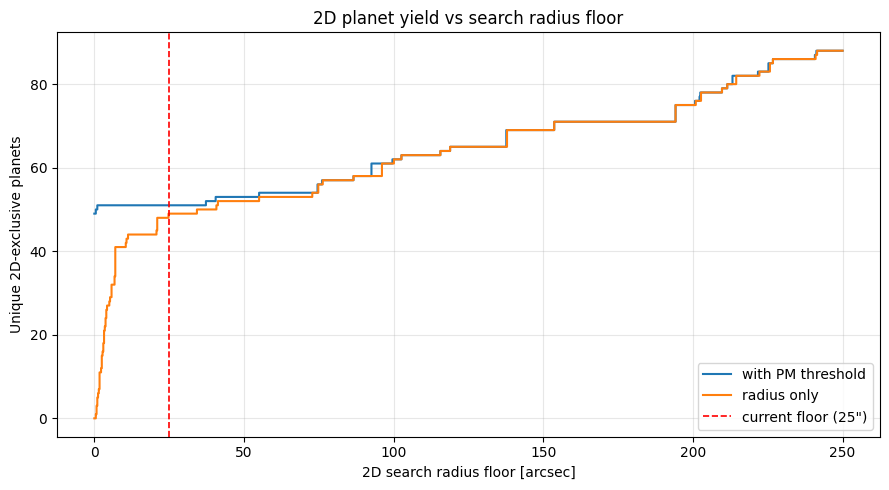

In [34]:
coords_in_sweep  = SkyCoord(ra=input_table["ra"]*u.deg, dec=input_table["dec"]*u.deg)
coords_cat_sweep = SkyCoord(ra=cm.catalogue["ra"]*u.deg, dec=cm.catalogue["dec"]*u.deg)
idx2d_sweep, sep2d_sweep, _ = coords_cat_sweep.match_to_catalog_sky(coords_in_sweep)

pm_term = allowed_angular_seperation(
    cm.catalogue["sy_pm"].filled(0) / 1000,
    cm.catalogue["sy_pmerr1"].filled(0) / 1000,
    cm.catalogue["coord_epoch"],
    minimum=0 * u.arcsec,
)

id_planet_set = set(cm.id_matched[uuid].tolist())
cat_planets   = np.array(cm.catalogue[uuid])
radii_arcsec  = np.linspace(0, 250, 1000)
current_r     = cm.search_radius_arcsec.to(u.arcsec).value

counts     = [len(set(cat_planets[sep2d_sweep < (pm_term + r*u.arcsec)]) - id_planet_set) for r in radii_arcsec]
counts_raw = [len(set(cat_planets[sep2d_sweep < r*u.arcsec]) - id_planet_set) for r in radii_arcsec]

fig, ax = plt.subplots(figsize=(9, 5))
ax.step(radii_arcsec, counts,     lw=1.5, label="with PM threshold")
ax.step(radii_arcsec, counts_raw, lw=1.5, label="radius only")
ax.axvline(current_r, color="red", linestyle="--", lw=1.2, label=f"current floor ({current_r:.0f}\")")
ax.set_xlabel("2D search radius floor [arcsec]")
ax.set_ylabel("Unique 2D-exclusive planets")
ax.set_title("2D planet yield vs search radius floor")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


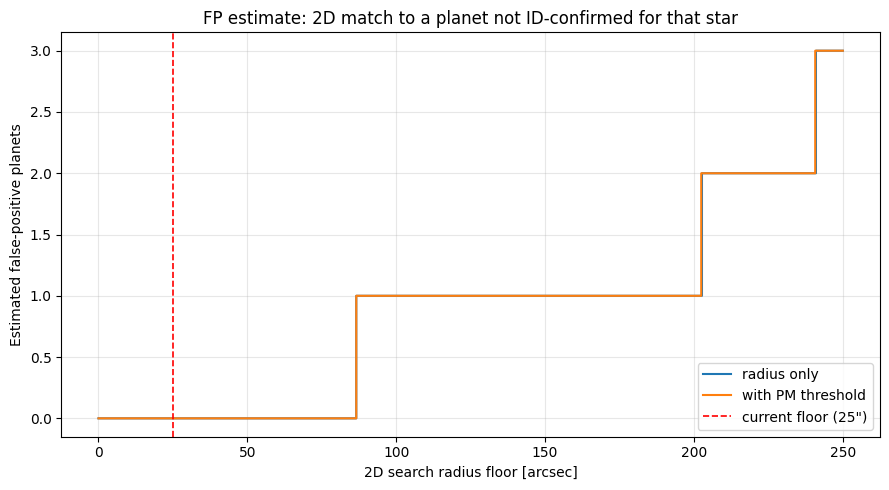

In [35]:
id_planets_per_star = {}
for row in cm.id_matched:
    id_planets_per_star.setdefault(str(row[cm.input_starname_key]), set()).add(str(row[uuid]))

in_names_arr = np.array([str(n) for n in input_table[cm.input_starname_key]])
cat_is_fp = np.array([
    (in_names_arr[i] in id_planets_per_star) and
    (str(p) not in id_planets_per_star[in_names_arr[i]])
    for i, p in zip(idx2d_sweep, cat_planets)
])

fp_pm  = [len(set(str(p) for p in cat_planets[(sep2d_sweep < (pm_term + r*u.arcsec)) & cat_is_fp])) for r in radii_arcsec]
fp_raw = [len(set(str(p) for p in cat_planets[(sep2d_sweep < r*u.arcsec) & cat_is_fp])) for r in radii_arcsec]

fig, ax = plt.subplots(figsize=(9, 5))
ax.step(radii_arcsec, fp_raw, lw=1.5, label="radius only")
ax.step(radii_arcsec, fp_pm,  lw=1.5, label="with PM threshold")
ax.axvline(current_r, color="red", linestyle="--", lw=1.2, label=f"current floor ({current_r:.0f}\")")
ax.set_xlabel("2D search radius floor [arcsec]")
ax.set_ylabel("Estimated false-positive planets")
ax.set_title("FP estimate: 2D match to a planet not ID-confirmed for that star")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
